# DOM-Graph RAG — Playground (Phase 1)

Ce notebook fait tourner la **Phase 1** de la méthodologie (construction du graphe guidée par le DOM) sur une page, du HTML brut jusqu'au graphe XML prêt pour un modèle lecteur.

Rappel des deux sources d'inspiration :
- **PixelRAG** — *PIXELRAG: Web Screenshots Beat Text for Retrieval-Augmented Generation* ([arXiv:2606.28344](https://arxiv.org/abs/2606.28344)) — rendu de la page en tuiles pixel, lues directement par un VLM.
- **MAGE-RAG** — *Multigranular Adaptive Graph Evidence for Agentic Multimodal RAG* ([arXiv:2606.15906](https://arxiv.org/abs/2606.15906)) — graphe à 2 niveaux (page / éléments) + contrôleur d'évidence en ligne.

Ici : le découpage en tuiles n'est plus une grille aveugle (comme PixelRAG) mais guidé par les éléments réels du DOM, puis organisé en graphe (à la MAGE-RAG).

In [10]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.dom_extraction import extract_dom_elements_async
from src.tiling import build_tiles
from src.graph_builder import build_graph, graph_to_xml
from src.corpus_builder import build_corpus_graph

import matplotlib.pyplot as plt
import networkx as nx

%matplotlib inline

## 1. Choix d'une page

In [18]:
#URL = FIXTURE.as_uri()
#URL = "https://en.wikipedia.org/wiki/Joel_Waterman"  
URL = "https://en.wikipedia.org/wiki/George_P._Gunn"
#URL = "https://en.wikipedia.org/wiki/Special:Random"
#URL = "https://www.bbc.com/news/articles/c5yd8gly1ydo"

print(f"URL : {URL}")

URL : https://en.wikipedia.org/wiki/George_P._Gunn


## 2. Extraction DOM

In [19]:
TILE_TAGS = ["figure", "img", "ol", "table","h1", "h2", "p", "h3"]

elements, screenshot = await extract_dom_elements_async(URL, element_tags=TILE_TAGS, wait_until="load")

print(f"{len(elements)} éléments extraits")
tags = sorted({e.tag for e in elements})
print("Balises :", tags)

for e in elements[:5]:
    print(f"  <{e.tag}> ({e.width:.0f}x{e.height:.0f}px) — {e.text_preview[:50]!r}")

11 éléments extraits
Balises : ['h2', 'img', 'ol', 'p', 'table']
  <table> (310x1051px) — 'The Right Reverend\nGeorge Purnell Gunn\nD.D.\nBishop'
  <img> (250x343px) — ''
  <p> (613x44px) — 'George Purnell Gunn (October 11, 1903 – June 16, 1'
  <h2> (252x27px) — 'Early life and education'
  <p> (603x226px) — 'Gunn was born on October 11, 1903, in Winona, Miss'


## 3. Tuilage adaptatif et patching

6 tuiles construites (contre 11 éléments DOM)


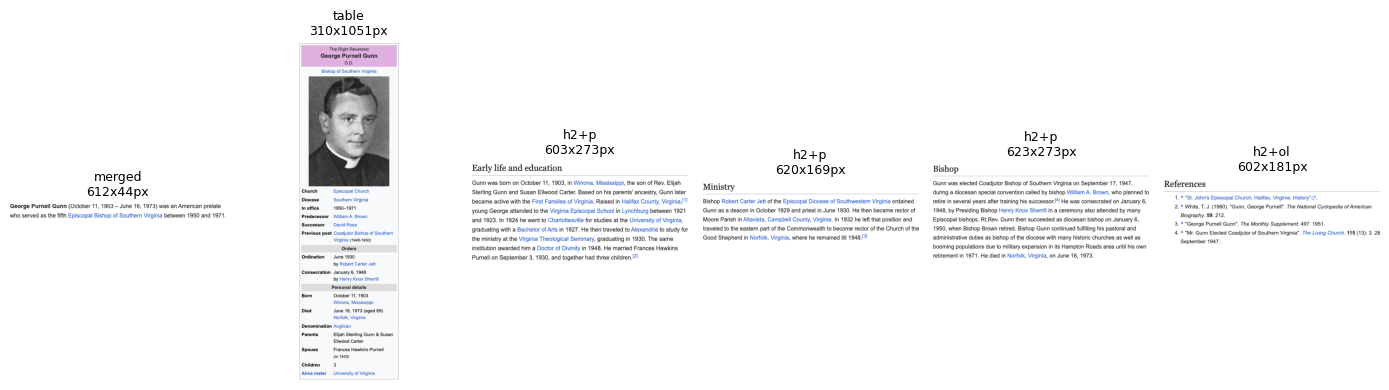

In [20]:
tiles = build_tiles(elements, screenshot)
print(f"{len(tiles)} tuiles construites (contre {len(elements)} éléments DOM)")

fig, axes = plt.subplots(1, min(len(elements), len(tiles)), figsize=(14, 4))
if len(tiles) == 1:
    axes = [axes]
for ax, tile in zip(axes, tiles[0:len(axes)]):
    ax.imshow(tile.image)
    ax.set_title(f"{tile.dom_tag}\n{tile.width}x{tile.height}px", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

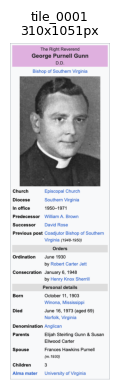

Total merged tiles: 1


In [21]:
merged_tiles = [tile for tile in tiles if tile.dom_tag == 'table']

fig, axes = plt.subplots(1, min(10, len(merged_tiles)), figsize=(14, 4))
if len(merged_tiles) == 1:
    axes = [axes]
    
for ax, tile in zip(axes, merged_tiles[:10]):
    ax.imshow(tile.image)
    ax.set_title(f"{tile.id}\n{tile.width}x{tile.height}px", fontsize=9)
    ax.axis("off")
    
plt.tight_layout()
plt.show()

print(f"Total merged tiles: {len(merged_tiles)}")

## 4. Construction du graphe

24 noeuds, 38 arêtes


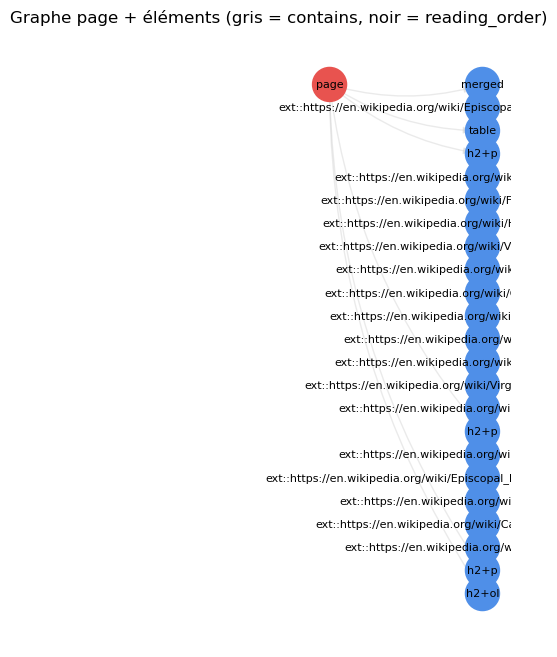

In [22]:
graph = build_graph(tiles, page_url=URL, page_title="Page de test")
print(f"{graph.number_of_nodes()} noeuds, {graph.number_of_edges()} arêtes")

pos = {"page": (0, 0)}
reading_order_nodes = [n for n in graph.nodes if n != "page"]
for i, n in enumerate(reading_order_nodes):
    pos[n] = (1, -i)

plt.figure(figsize=(6, 8))
colors = ["#e8534f" if n == "page" else "#4f8fe8" for n in graph.nodes]
labels = {n: ("page" if n == "page" else graph.nodes[n].get("tag", str(n))) for n in graph.nodes}

contains_edges = [(u, v) for u, v, d in graph.edges(data=True) if d["relation"] == "contains"]
order_edges = [(u, v) for u, v, d in graph.edges(data=True) if d["relation"] == "reading_order"]

nx.draw_networkx_nodes(graph, pos, node_color=colors, node_size=600)
nx.draw_networkx_labels(graph, pos, labels=labels, font_size=8)
nx.draw_networkx_edges(graph, pos, edgelist=contains_edges, edge_color="#ccc", alpha=0.4, connectionstyle="arc3,rad=0.15")
nx.draw_networkx_edges(graph, pos, edgelist=order_edges, edge_color="#333", arrows=True)
plt.title("Graphe page + éléments (gris = contains, noir = reading_order)")
plt.axis("off")
plt.show()


In [23]:
from pyvis.network import Network
from IPython.display import display, HTML
from urllib.parse import urlparse, unquote
import networkx as nx

# 1. Construction du graphe
graph = build_graph(tiles, page_url=URL, page_title="Page de test")
print(f"{graph.number_of_nodes()} noeuds, {graph.number_of_edges()} arêtes")

# 2. Préparation des attributs visuels directement dans le graphe NetworkX
for n, data in graph.nodes(data=True):
    if n == "page":
        graph.nodes[n]['color'] = "#e8534f"
        graph.nodes[n]['label'] = "Page Web"
        graph.nodes[n]['size'] = 25
        graph.nodes[n]['title'] = f"<b>URL cible :</b><br>{URL}"
    elif data.get('type') == 'external_page':
        # Lien hypertexte trouvé dans le texte (arête "links_to"), pas encore
        # crawlé -- cf. build_graph. Sans ce cas, il tombe dans le "else"
        # ci-dessous : `tag` n'existe pas sur ces noeuds (seulement `type` et
        # `url`), donc le label affiché est le "?" de secours de `.get('tag', '?')`.
        link_url = data.get('url', '')
        article = unquote(urlparse(link_url).path.rsplit('/', 1)[-1]).replace('_', ' ')
        graph.nodes[n]['color'] = "#e87ba4"
        graph.nodes[n]['label'] = article or "lien externe"
        graph.nodes[n]['size'] = 12
        graph.nodes[n]['title'] = f"<b>Lien externe (non crawlé) :</b><br>{link_url}"
    else:
        graph.nodes[n]['color'] = "#4f8fe8"
        
        tag = data.get('tag', '?')
        width = data.get('width', '?')
        height = data.get('height', '?')
        state = data.get('state', 'unknown')
        text = data.get('text_preview', '')
        
        # Deux tuiles différentes peuvent partager le même tag composé (ex.
        # deux sections "h2+p" distinctes) : un label réduit au tag donnerait
        # l'impression trompeuse de deux noeuds identiques. On ajoute un court
        # extrait du texte pour les distinguer visuellement.
        label_excerpt = (text[:28] + "…") if len(text) > 28 else text
        graph.nodes[n]['label'] = f"{tag}\n{label_excerpt}" if label_excerpt else tag
        graph.nodes[n]['size'] = 15
        
        if len(text) > 100:
            text = text[:100] + "..."
            
        tooltip = f"""
        <b>Tag :</b> &lt;{tag}&gt;<br>
        <b>Dimensions :</b> {width} x {height} px<br>
        <b>État :</b> {state}<br>
        <hr>
        <b>Extrait :</b><br><i>{text}</i>
        """
        graph.nodes[n]['title'] = tooltip

# 3. Initialisation
net = Network(notebook=True, width="100%", height="600px", directed=True, cdn_resources='in_line')

# 4. Conversion du graphe NetworkX vers Pyvis
net.from_nx(graph)

# 5. Personnalisation du style des arêtes selon leur relation
for edge in net.edges:
    if edge.get("relation") == "contains":
        edge["color"] = "rgba(204, 204, 204, 0.6)" # Gris transparent
        edge["physics"] = False 
    elif edge.get("relation") == "reading_order":
        edge["color"] = "#333333" # Noir
        edge["arrows"] = "to"

net.show("dom_graph.html")

24 noeuds, 38 arêtes
dom_graph.html


In [24]:
import base64
from io import BytesIO
from pyvis.network import Network
from IPython.display import display, HTML
from urllib.parse import urlparse, unquote
import networkx as nx

# 1. Construction du graphe
graph = build_graph(tiles, page_url=URL, page_title="Page de test")
print(f"{graph.number_of_nodes()} noeuds, {graph.number_of_edges()} arêtes")

# Création d'un dictionnaire pour retrouver facilement la tuile à partir de l'ID du noeud
# (On suppose ici que l'ID du noeud 'n' correspond à l'attribut 'id' de la tuile)
tiles_dict = {tile.id: tile for tile in tiles}

# 2. Préparation des attributs visuels directement dans le graphe NetworkX
for n, data in graph.nodes(data=True):
    if n == "page":
        graph.nodes[n]['color'] = "#e8534f"
        graph.nodes[n]['label'] = "Page Web"
        graph.nodes[n]['size'] = 25
        # Texte simple pour la page racine pour éviter l'affichage de balises brutes
        graph.nodes[n]['title'] = f"URL cible : {URL}" 
    elif data.get('type') == 'external_page':
        # Lien hypertexte trouvé dans le texte (arête "links_to"), pas encore
        # crawlé -- cf. build_graph. Sans ce cas, il tombe dans le "else"
        # ci-dessous : `tag` n'existe pas sur ces noeuds (seulement `type` et
        # `url`), donc le label affiché est le "?" de secours de `.get('tag', '?')`.
        link_url = data.get('url', '')
        article = unquote(urlparse(link_url).path.rsplit('/', 1)[-1]).replace('_', ' ')
        graph.nodes[n]['color'] = "#e87ba4"
        graph.nodes[n]['label'] = article or "lien externe"
        graph.nodes[n]['size'] = 12
        graph.nodes[n]['title'] = f"Lien externe (non crawlé) : {link_url}"
    else:
        graph.nodes[n]['color'] = "#4f8fe8"
        
        tag = data.get('tag', '?')
        width = data.get('width', '?')
        height = data.get('height', '?')
        state = data.get('state', 'unknown')
        text_preview = data.get('text_preview', '')
        
        # cf. cellule précédente : deux tuiles différentes peuvent partager le
        # même tag composé (ex. deux sections "h2+p" distinctes) -- on ajoute
        # un court extrait du texte pour éviter que leurs labels ne soient
        # identiques et ne donnent l'impression trompeuse de noeuds dupliqués.
        label_excerpt = (text_preview[:28] + "…") if len(text_preview) > 28 else text_preview
        graph.nodes[n]['label'] = f"{tag}\n{label_excerpt}" if label_excerpt else tag
        graph.nodes[n]['size'] = 15
        
        # --- GESTION DE L'IMAGE AU SURVOL ---
        # On initialise une infobulle de secours en texte simple
        tooltip_html = f"Tag: <{tag}> | Dimensions: {width}x{height} | Etat: {state}"
        
        # Récupération de la tuile correspondante au noeud
        tile = tiles_dict.get(n)
        
        # Si la tuile contient bien une image
        if tile and hasattr(tile, 'image'):
            buffered = BytesIO()
            
            # On sauvegarde l'image (PIL Image) dans le buffer virtuel au format PNG
            # (Si tile.image est un array numpy, il faudrait faire : Image.fromarray(tile.image).save(...))
            tile.image.save(buffered, format="PNG")
            
            # Encodage de l'image en base64
            img_str = base64.b64encode(buffered.getvalue()).decode('utf-8')
            
            # On crée une vraie structure HTML (un <div> contenant l'image)
            # max-width: 300px évite que l'infobulle ne prenne tout l'écran
            tooltip_html = f'<div><img src="data:image/png;base64,{img_str}" style="max-width: 300px; border: 1px solid #ccc; border-radius: 4px; box-shadow: 2px 2px 5px rgba(0,0,0,0.2);"></div>'
            
        # On assigne l'HTML formaté à l'attribut title du noeud Pyvis
        graph.nodes[n]['title'] = tooltip_html

# 3. Initialisation
net = Network(notebook=True, width="100%", height="600px", directed=True, cdn_resources='in_line')

# 4. Conversion du graphe NetworkX vers Pyvis
net.from_nx(graph)

# 5. Personnalisation du style des arêtes selon leur relation
for edge in net.edges:
    if edge.get("relation") == "contains":
        edge["color"] = "rgba(204, 204, 204, 0.6)" # Gris transparent
        edge["physics"] = False 
    elif edge.get("relation") == "reading_order":
        edge["color"] = "#333333" # Noir
        edge["arrows"] = "to"

# 6. Affichage
net.show("dom_graph_new.html")

24 noeuds, 38 arêtes
dom_graph_new.html


## 4b. Interconnexion entre les pages

In [9]:
import base64
from io import BytesIO
from pyvis.network import Network
from IPython.display import display, HTML

# 1. Construction du corpus (votre code existant)
corpus = await build_corpus_graph(URL, max_linked_pages=3)
print(f"{corpus.number_of_nodes()} noeuds, {corpus.number_of_edges()} arêtes")

page_nodes = [n for n, d in corpus.nodes(data=True) if d.get("type") == "page"]
print(f"\n{len(page_nodes)} pages dans le corpus :")
for n in page_nodes:
    print(f"  - {n} -> {corpus.nodes[n]['url']}")

links_to = [(u, v) for u, v, d in corpus.edges(data=True) if d.get("relation") == "links_to"]
print(f"\n{len(links_to)} arêtes 'links_to' (inter-pages) :")
for u, v in links_to:
    print(f"  {u} -> {v}")

151 noeuds, 494 arêtes

4 pages dans le corpus :
  - George_P._Gunn::page -> https://en.wikipedia.org/wiki/George_P._Gunn
  - Episcopal_Diocese_of_Southern_Virginia::page -> https://en.wikipedia.org/wiki/Episcopal_Diocese_of_Southern_Virginia
  - Winona__Mississippi::page -> https://en.wikipedia.org/wiki/Winona,_Mississippi
  - First_Families_of_Virginia::page -> https://en.wikipedia.org/wiki/First_Families_of_Virginia

54 arêtes 'links_to' (inter-pages) :
  George_P._Gunn::tile_0000 -> Episcopal_Diocese_of_Southern_Virginia::page
  George_P._Gunn::tile_0002 -> George_P._Gunn::ext::https://en.wikipedia.org/wiki/Halifax_County,_Virginia
  George_P._Gunn::tile_0002 -> George_P._Gunn::ext::https://en.wikipedia.org/wiki/Virginia_Episcopal_School
  George_P._Gunn::tile_0002 -> George_P._Gunn::ext::https://en.wikipedia.org/wiki/Lynchburg,_Virginia
  George_P._Gunn::tile_0002 -> George_P._Gunn::ext::https://en.wikipedia.org/wiki/Charlottesville,_Virginia
  George_P._Gunn::tile_0002 -> George_

In [10]:
vis = corpus.copy()
for n, data in vis.nodes(data=True):
    if data.get("type") == "page":
        data['color'] = "#e8534f"
        data['label'] = str(n)
        data['size'] = 25
        data['title'] = f"<b>Page :</b><br>{data.get('url', '')}"
        
    elif data.get("type") == "external_page":
        # Page mentionnée mais pas encore crawlée
        data['color'] = "#e87ba4"
        data['label'] = "?"
        data['size'] = 18
        data['title'] = f"<b>Non crawlée :</b><br>{data.get('url', '')}"
        
    else:
        # Nœuds "éléments" (les tuiles)
        data['color'] = "#4f8fe8"
        tag = data.get('tag', str(n))
        text = data.get('text_preview', '')
        
        if len(text) > 100:
            text = text[:100] + "..."
            
        data['label'] = tag
        data['size'] = 15
        
        # --- GESTION DE L'IMAGE AU SURVOL ---
        # On initialise une infobulle textuelle de base au cas où l'image manquerait
        tooltip_html = f"<div><b>Tag :</b> &lt;{tag}&gt;<br><hr><b>Extrait :</b><br><i>{text}</i></div>"
        
        # On cherche l'image (selon comment build_corpus_graph la stocke dans le graphe)
        img_obj = data.get('image')
        if not img_obj and data.get('tile'):
            img_obj = data.get('tile').image
            
        if img_obj:
            try:
                buffered = BytesIO()
                img_obj.save(buffered, format="PNG")
                img_str = base64.b64encode(buffered.getvalue()).decode('utf-8')
                
                # On met à jour l'infobulle avec la balise <img>
                tooltip_html = f"""
                <div style="font-family: sans-serif; font-size: 12px;">
                    <b>Tag :</b> &lt;{tag}&gt;<br>
                    <hr>
                    <b>Extrait :</b><br><i>{text}</i><br><br>
                    <img src="data:image/png;base64,{img_str}" style="max-width: 300px; border: 1px solid #ccc; border-radius: 4px; box-shadow: 2px 2px 5px rgba(0,0,0,0.2);">
                </div>
                """
            except Exception as e:
                # Si la conversion échoue, on garde le tooltip texte basique
                pass
                
        data['title'] = tooltip_html

# 3. Initialisation et affichage Pyvis
net = Network(notebook=True, width="100%", height="700px", directed=True, cdn_resources='in_line')
net.from_nx(vis)

for edge in net.edges:
    relation = edge.get("relation")
    if relation == "contains":
        edge["color"] = "rgba(204, 204, 204, 0.6)"
        edge["physics"] = False
    elif relation == "reading_order":
        edge["color"] = "#333333"
        edge["arrows"] = "to"
    elif relation == "links_to":
        # Arête inter-pages
        edge["color"] = "#eda100"
        edge["width"] = 3
        edge["arrows"] = "to"

net.show("dom_graph_corpus_new.html")

dom_graph_corpus_new.html


In [11]:
from pyvis.network import Network

vis = corpus.copy()
for n, data in vis.nodes(data=True):
    if data.get("type") == "page":
        data['color'] = "#e8534f"
        data['label'] = str(n)
        data['size'] = 25
        data['title'] = f"<b>Page :</b><br>{data.get('url', '')}"
    elif data.get("type") == "external_page":
        # Page mentionnée mais pas encore crawlée (au-delà de max_linked_pages)
        data['color'] = "#e87ba4"
        data['label'] = "?"
        data['size'] = 18
        data['title'] = f"<b>Non crawlée :</b><br>{data.get('url', '')}"
    else:
        data['color'] = "#4f8fe8"
        tag = data.get('tag', str(n))
        text = data.get('text_preview', '')[:100]
        data['label'] = tag
        data['size'] = 12
        data['title'] = f"<b>Tag :</b> &lt;{tag}&gt;<br>{text}"

net = Network(notebook=True, width="100%", height="700px", directed=True, cdn_resources='in_line')
net.from_nx(vis)

for edge in net.edges:
    relation = edge.get("relation")
    if relation == "contains":
        edge["color"] = "rgba(204, 204, 204, 0.6)"
        edge["physics"] = False
    elif relation == "reading_order":
        edge["color"] = "#333333"
        edge["arrows"] = "to"
    elif relation == "links_to":
        # Arête inter-pages : c'est elle qui interconnecte les graphes entre eux
        edge["color"] = "#eda100"
        edge["width"] = 3
        edge["arrows"] = "to"

net.show("dom_graph_corpus.html")

dom_graph_corpus.html


## 5. Export XML

In [12]:
xml_output = graph_to_xml(graph)
print(xml_output[:1500])

<?xml version="1.0" ?>
<page url="https://en.wikipedia.org/wiki/George_P._Gunn" title="URL cible : https://en.wikipedia.org/wiki/George_P._Gunn">
  <element id="tile_0000" tag="merged" state="inactive">George Purnell Gunn (October 11, 1903 – June 16, 1973) was an American prelate who served as the fifth Episcopal Bishop of Southern Virginia between 1950 and 1971.</element>
  <element id="tile_0001" tag="table" state="inactive">The Right Reverend
George Purnell Gunn
D.D.
Bishop of Southern Virginia

Church	Episcopal Church
Diocese	Southern Virginia
In office	1950–1971
Predecessor	William A. Brown
Successor	David Rose
Previou</element>
  <element id="tile_0002" tag="h2+p" state="inactive">Early life and education Gunn was born on October 11, 1903, in Winona, Mississippi, the son of Rev. Elijah Sterling Gunn and Susan Ellwood Carter. Based on his parents' ancestry, Gunn later became act</element>
  <element id="tile_0003" tag="h2+p" state="inactive">Ministry Bishop Robert Carter Jett of t

## 6. Test VLM

In [13]:
from src.vlm_client import VLMClient

try:
    client = VLMClient(backend="ollama")
    tile = tiles[1] if len(tiles) > 1 else tiles[0]
    reponse = client.ask(tile.image, "Describe the content of the web page.")
    print(reponse)
except Exception as exc:
    print(f"VLM non available ({exc})")

The web page is a biographical profile of **George Purnell Gunn (D.D.)**, identified as *The Right Reverend* and **Bishop of Southern Virginia**. It is structured to provide detailed information about his ecclesiastical role, personal history, and career milestones.  

### Key Sections & Content:  
1. **Header & Photo**:  
   - A purple header displays his title (*The Right Reverend George Purnell Gunn D.D.*) and position (*Bishop of Southern Virginia*).  
   - Below the header is a black-and-white photograph of Gunn in clerical attire (a dark suit with a white collar, typical of Episcopal clergy).  

2. **Ecclesiastical Details**:  
   - **Church**: Episcopal Church  
   - **Diocese**: Southern Virginia  
   - **In office**: 1950–1971  
   - **Predecessor**: William A. Brown  
   - **Successor**: David Rose  
   - **Previous post**: Coadjutor Bishop of Southern Virginia (1948–1950)  

3. **Orders (Ordination & Consecration)**:  
   - **Ordination**: June 1930, performed by *Robert Car

## 7. Phase 2a — génération de paires question/réponse par tuile

Le VLM lit chaque tuile construite plus haut (section 3) et pose une question dont la réponse n'est visible que dans cette tuile — ce sont les exemples positifs de l'entraînement contrastif. Toutes les tuiles sont sauvegardées sur disque (`data/qa_dataset/images/`), pas seulement celles qui ont donné une question, pour que le hard-negative mining puisse ensuite y piocher des négatifs.

In [14]:
from src.qa_generation import generate_qa_dataset
from src.corpus_builder import slug_for_url

page_slug = slug_for_url(URL)

try:
    qa_pairs = generate_qa_dataset(tiles, page_url=URL, page_slug=page_slug)
    print(f"{len(qa_pairs)} paires question/réponse générées (sur {len(tiles)} tuiles)")
    for qa in qa_pairs[:5]:
        print(f"  [{qa.tile_id}] Q : {qa.question}")
        print(f"           R : {qa.answer}")
except Exception as exc:
    print(f"VLM non disponible ({exc}) — génération QA sautée")
    qa_pairs = []

6 paires question/réponse générées (sur 6 tuiles)
  [tile_0000] Q : What was George Purnell Gunn's title as stated in the image?
           R : fifth Episcopal Bishop of Southern Virginia
  [tile_0001] Q : How many children did George Purnell Gunn have?
           R : 3
  [tile_0002] Q : In what year did Gunn graduate with his Bachelor of Arts degree?
           R : 1927
  [tile_0003] Q : In what month and year was Gunn ordained as a priest?
           R : June 1930
  [tile_0004] Q : On what date did Bishop Gunn die?
           R : June 16, 1973


## 8. Phase 2b — hard-negative mining

Pour chaque question, on sélectionne quelques tuiles de la même page lexicalement proches (TF-IDF + cosinus) mais qui ne contiennent pas la réponse : des négatifs "difficiles", plus utiles à l'entraînement qu'une tuile prise au hasard.

In [15]:
from src.hard_negative_mining import mine_hard_negatives, save_contrastive_examples

contrastive_examples = mine_hard_negatives(qa_pairs, tiles)
print(f"{len(contrastive_examples)} exemples contrastifs construits")

if contrastive_examples:
    save_contrastive_examples(contrastive_examples)
    example = contrastive_examples[0]
    print(f"\nQuestion : {example.question}")
    print(f"  Tuile positive : {example.positive_tile_id}")
    print(f"  Négatifs difficiles : {example.hard_negative_tile_ids}")

AttributeError: module 'numpy._globals' has no attribute '_signature_descriptor'

6 exemples contrastifs construits

Question : What was George Purnell Gunn's title as stated in the image?
  Tuile positive : tile_0000
  Négatifs difficiles : ['tile_0005', 'tile_0002']


## 8b. Fine-tuning LoRA et checkpoints

Ce bloc lance le fine-tuning LoRA sur le dataset contrastif et sauvegarde un checkpoint à chaque epoch.


In [16]:
# 8b. Fine-tuning LoRA et checkpoints
# L'entraînement fine-tune le VLM lecteur avec l'adaptateur LoRA,
# sauvegarde un checkpoint à chaque epoch et un modèle final.

try:
    from src.lora_finetune import train_lora, TrainConfig

    config = TrainConfig(
        epochs=3,
        batch_size=2,
        lr=1e-4,
        n_negatives=4,
        output_dir="data/lora_reader_adapter",
        checkpoint_every=1,
    )

    print(f"Démarrage du fine-tuning LoRA avec checkpoints dans {config.output_dir}...")
    train_lora(config)
except ImportError as exc:
    print(f"Environnement de fine-tuning non disponible ({exc}) — installe torch/transformers/peft et relance la cellule.")
except Exception as exc:
    print(f"Erreur pendant le fine-tuning : {exc}")


Démarrage du fine-tuning LoRA avec checkpoints dans data/lora_reader_adapter...


/opt/anaconda3/lib/python3.11/site-packages/torch/_subclasses/functional_tensor.py:368: UserWarning: Failed to initialize NumPy: cannot load module more than once per process (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:84.)
  cpu = _conversion_method_template(device=torch.device("cpu"))


ImportError: cannot load module more than once per process

Environnement de fine-tuning non disponible (numpy._core.multiarray failed to import) — installe torch/transformers/peft et relance la cellule.


## 9. Dataset contrastif prêt pour le fine-tuning LoRA

`ContrastiveTileDataset` relit les fichiers `.jsonl` accumulés dans `data/qa_dataset/` (toutes pages confondues, si le notebook a tourné sur plusieurs URLs) et assemble des batches (question, tuile positive, tuiles négatives) au format attendu par `src/lora_finetune.py`. Cette dernière étape (l'entraînement LoRA à proprement parler) nécessite torch + transformers + peft et idéalement un GPU — voir `requirements.txt` (section Phase 2) et lancer ensuite :
```bash
python3 -m src.lora_finetune --epochs 3 --batch-size 4
```

In [17]:
try:
    from src.contrastive_dataset import ContrastiveTileDataset, contrastive_collate_fn
    from torch.utils.data import DataLoader

    dataset = ContrastiveTileDataset()
    print(f"{len(dataset)} exemples dans le dataset contrastif accumulé (data/qa_dataset/)")

    if len(dataset) > 0:
        loader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=contrastive_collate_fn)
        batch = next(iter(loader))
        print(f"Batch : {len(batch['questions'])} questions, {len(batch['tile_images'])} images de tuiles")
except ImportError as exc:
    print(f"torch non installé ({exc}) — décommenter la section Phase 2 de requirements.txt pour l'entraînement LoRA")

6 exemples dans le dataset contrastif accumulé (data/qa_dataset/)
Batch : 2 questions, 6 images de tuiles


## 10. Phase 3 — contrôleur d'évidence en ligne

Jusqu'ici chaque noeud élément portait un attribut `state` figé à `"inactive"` (posé par `build_graph`, cf. Phase 1d). Le contrôleur d'évidence de `src/evidence_controller.py` le fait maintenant évoluer **étant donné une requête**, selon une politique d'actions sous budget inspirée de l'Algorithme 1 de MAGE-RAG :

```
inactive --(activation)--> active --(ouverture)--> opened
                              \\--(élagage)-------> pruned
```

- **seed** : les noeuds les plus pertinents pour la requête (TF-IDF + cosinus) passent `inactive → active`.
- **open** : le noeud actif le plus pertinent est "ouvert" (consomme une unité de `budget`) — son contenu devient de l'évidence, et ses voisins en ordre de lecture encore inactifs sont activés à leur tour si assez pertinents (la frontière avance).
- **prune** : un noeud actif trop peu pertinent est élagué sans consommer de budget ; les noeuds encore actifs une fois le budget épuisé sont élagués aussi.

Résultat : un sous-ensemble élagué et priorisé du graphe (les noeuds `"opened"`) sert d'évidence au modèle lecteur, au lieu de lui donner toute la page.

In [18]:
from src.evidence_controller import EvidenceControllerConfig, run_evidence_controller, state_counts, collect_evidence

# Requête utilisateur simulée : c'est elle qui pilote la politique d'ouverture/élagage.
QUERY = "When and where was George Purnell Gunn born?"

# Graphe propre (les cellules de visualisation Pyvis ci-dessus ont annoté `graph`
# avec des attributs "color"/"title" à but d'affichage) sur lequel faire tourner le contrôleur.
evidence_graph = build_graph(tiles, page_url=URL, page_title="Page de test")

controller_config = EvidenceControllerConfig(budget=4, top_k_seed=2, use_vlm=False)
action_log = run_evidence_controller(evidence_graph, tiles, QUERY, controller_config)

print(f"Requête : {QUERY!r}\n")
for entry in action_log:
    print(f"  [{entry.step:02d}] {entry.action:10s} {entry.node_id:12s} score={entry.score:.3f}  ({entry.state_before} -> {entry.state_after})")

print(f"\nRépartition finale des états : {state_counts(evidence_graph)}")

ImportError: cannot load module more than once per process

Requête : 'When and where was George Purnell Gunn born?'

  [00] seed       tile_0002    score=0.373  (inactive -> active)
  [01] seed       tile_0005    score=0.354  (inactive -> active)
  [02] open       tile_0002    score=0.373  (active -> opened)
  [03] activate   tile_0001    score=0.172  (inactive -> active)
  [04] activate   tile_0003    score=0.104  (inactive -> active)
  [05] open       tile_0005    score=0.354  (active -> opened)
  [06] activate   tile_0004    score=0.112  (inactive -> active)
  [07] open       tile_0001    score=0.172  (active -> opened)
  [08] activate   tile_0000    score=0.340  (inactive -> active)
  [09] open       tile_0000    score=0.340  (active -> opened)
  [10] prune      tile_0003    score=0.104  (active -> pruned)
  [11] prune      tile_0004    score=0.112  (active -> pruned)

Répartition finale des états : {'inactive': 0, 'active': 0, 'opened': 4, 'pruned': 2}


In [19]:
from pyvis.network import Network

STATE_COLORS = {
    "inactive": "#cccccc",
    "active": "#f5a623",
    "opened": "#4caf50",
    "pruned": "#e57373",
}

vis = evidence_graph.copy()
for n, data in vis.nodes(data=True):
    if data.get("type") == "page":
        data["color"] = "#e8534f"
        data["label"] = "Page Web"
        data["size"] = 25
        data["title"] = f"URL cible : {URL}"
    else:
        state = data.get("state", "inactive")
        tag = data.get("tag", "?")
        score = data.get("relevance_score", 0.0)
        text = (data.get("evidence") or data.get("text_preview", ""))[:150]

        data["color"] = STATE_COLORS.get(state, "#cccccc")
        data["label"] = f"{tag}\n[{state}]"
        data["size"] = 12 + 8 * score
        data["title"] = f"<b>&lt;{tag}&gt; — état : {state}</b><br>score={score:.3f}<hr>{text}"

net = Network(notebook=True, width="100%", height="600px", directed=True, cdn_resources="in_line")
net.from_nx(vis)

for edge in net.edges:
    relation = edge.get("relation")
    if relation == "contains":
        edge["color"] = "rgba(204, 204, 204, 0.6)"
        edge["physics"] = False
    elif relation == "reading_order":
        edge["color"] = "#333333"
        edge["arrows"] = "to"

net.show("dom_graph_evidence.html")

dom_graph_evidence.html


In [20]:
evidence_text = collect_evidence(evidence_graph)
print("Évidence finale (noeuds 'opened', dans l'ordre de lecture) :\n")
print(evidence_text)

print("\n--- Export XML (état par noeud, cf. graph_to_xml) ---\n")
print(graph_to_xml(evidence_graph))

Évidence finale (noeuds 'opened', dans l'ordre de lecture) :

George Purnell Gunn (October 11, 1903 – June 16, 1973) was an American prelate who served as the fifth Episcopal Bishop of Southern Virginia between 1950 and 1971.

The Right Reverend
George Purnell Gunn
D.D.
Bishop of Southern Virginia

Church	Episcopal Church
Diocese	Southern Virginia
In office	1950–1971
Predecessor	William A. Brown
Successor	David Rose
Previou

Early life and education Gunn was born on October 11, 1903, in Winona, Mississippi, the son of Rev. Elijah Sterling Gunn and Susan Ellwood Carter. Based on his parents' ancestry, Gunn later became act

References "St. John's Episcopal Church, Halifax, Virginia: History".
 White, T. J. (1980). "Gunn, George Purnell". The National Cyclopedia of American Biography. 59: 212.
 "George Purnell Gunn". The 

--- Export XML (état par noeud, cf. graph_to_xml) ---

<?xml version="1.0" ?>
<page url="https://en.wikipedia.org/wiki/George_P._Gunn" title="Page de test">
  <element

## Prochaines étapes

- **Phase 2** — entraînement contrastif : générer des paires question/réponse par tuile, ajouter du hard-negative mining, fine-tuner (LoRA) le VLM lecteur sur le ViT + LLM.
- **Phase 3** — contrôleur d'évidence en ligne (implémentée ci-dessus, `src/evidence_controller.py`) : l'attribut `state` de chaque noeud évolue (`inactive` → `active` → `opened`/`pruned`) selon une politique d'actions sous budget, comme dans MAGE-RAG.
- **Phase 4** — évaluation sur LongDocURL / MMLongBench-Doc / SimpleQA, diagnostic parser/rank/reader loss, rédaction.

Voir le `README.md` du projet pour plus de détails sur chaque étape.